In [ ]:
import yfinance as yf
from datetime import datetime

# Get the stock quote for Apple using yfinance
df = yf.download('AAPL', start='2014-10-29', end=datetime.now())

# Display the data
print(df)

[*********************100%***********************]  1 of 1 completed

Price                       Adj Close       Close        High         Low  \
Ticker                           AAPL        AAPL        AAPL        AAPL   
Date                                                                        
2014-10-29 00:00:00+00:00   23.800802   26.834999   26.842501   26.590000   
2014-10-30 00:00:00+00:00   23.720982   26.745001   26.837500   26.475000   
2014-10-31 00:00:00+00:00   23.947149   27.000000   27.010000   26.802500   
2014-11-03 00:00:00+00:00   24.257574   27.350000   27.575001   27.002501   
2014-11-04 00:00:00+00:00   24.080185   27.150000   27.372499   26.930000   
...                               ...         ...         ...         ...   
2024-11-22 00:00:00+00:00  229.869995  229.869995  230.720001  228.059998   
2024-11-25 00:00:00+00:00  232.869995  232.869995  233.250000  229.740005   
2024-11-26 00:00:00+00:00  235.059998  235.059998  235.570007  233.330002   
2024-11-27 00:00:00+00:00  234.929993  234.929993  235.690002  233.809998   

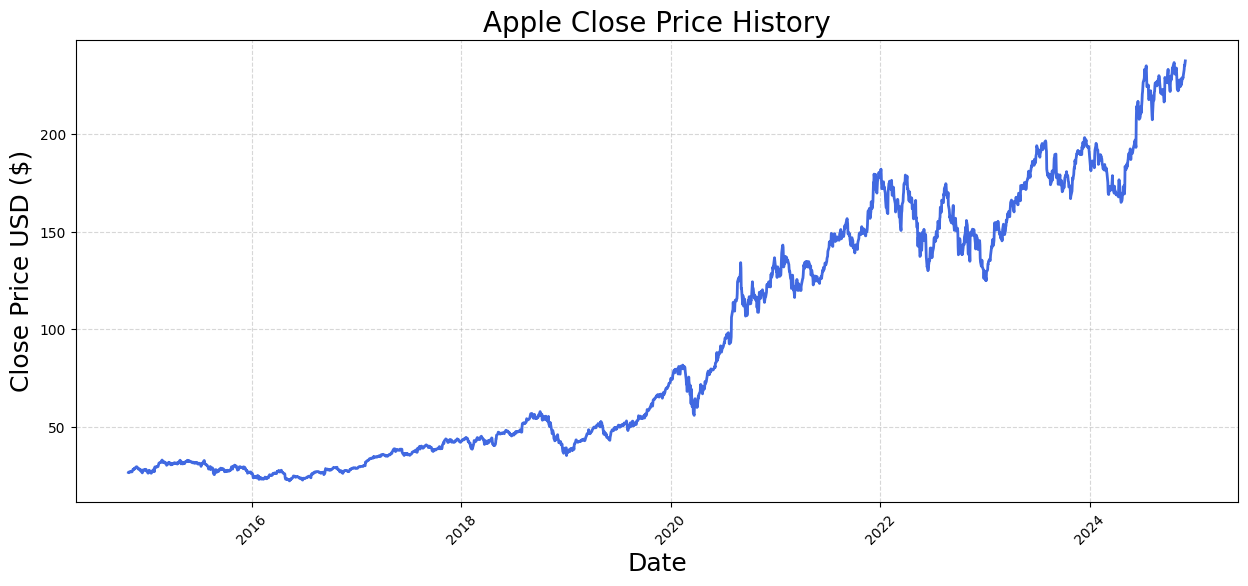

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.title('Apple Close Price History', fontsize=20)
plt.plot(df['Close'], color='royalblue', linewidth=2)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
import numpy as np

# Create a new dataframe with only the 'Close' column
data = df.filter(['Close'])

# Convert the dataframe to a numpy array
dataset = data.values

# Get the number of rows to train the model on (95% of dataset)
training_data_len = int(np.ceil(len(dataset) * 0.95))

training_data_len

2413

In [ ]:

from sklearn.preprocessing import MinMaxScaler

if 'Close' in df.columns:
    data = df[['Close']]
else:
    data = df[['close']]

# Convert the dataframe to a numpy array
dataset = data.values

# Get the number of rows to train the model on (95% of dataset)
training_data_len = int(np.ceil(len(dataset) * 0.95))

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.01979091],
       [0.01937182],
       [0.02055927],
       ...,
       [0.9894293 ],
       [0.98882391],
       [1.        ]])

In [ ]:
# Create the training data set
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]

# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

[array([0.01979091, 0.01937182, 0.02055927, 0.02218911, 0.02125777,
       0.02156046, 0.02137419, 0.02173509, 0.02152554, 0.02253836,
       0.02434283, 0.02617058, 0.02775385, 0.02753266, 0.02925563,
       0.02832429, 0.03023353, 0.03041981, 0.03293441, 0.03173532,
       0.03336516, 0.03328367, 0.02878996, 0.02827773, 0.02979115,
       0.02927891, 0.02870847, 0.02568163, 0.027684  , 0.02515775,
       0.02477358, 0.02257329, 0.02082704, 0.01910406, 0.02220076,
       0.02597267, 0.02495984, 0.02631028, 0.02584461, 0.0252276 ,
       0.02753266, 0.02743953, 0.02582132, 0.02333   , 0.02210762,
       0.01852197, 0.01853362, 0.02026823, 0.0250879 , 0.0252276 ,
       0.02201449, 0.02314373, 0.02265478, 0.01918555, 0.01821928,
       0.02139748, 0.02236374, 0.02568163, 0.02635685, 0.02649654])]
[0.02188642670528576]

[array([0.01979091, 0.01937182, 0.02055927, 0.02218911, 0.02125777,
       0.02156046, 0.02137419, 0.02173509, 0.02152554, 0.02253836,
       0.02434283, 0.02617058, 0.02

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2353/2353 ━━━━━━━━━━━━━━━━━━━━ 148s 61ms/step - loss: 0.0043


In [ ]:
# Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 247ms/step


12.684227257372658

<ipython-input-8-0cdd5e68a3a9>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


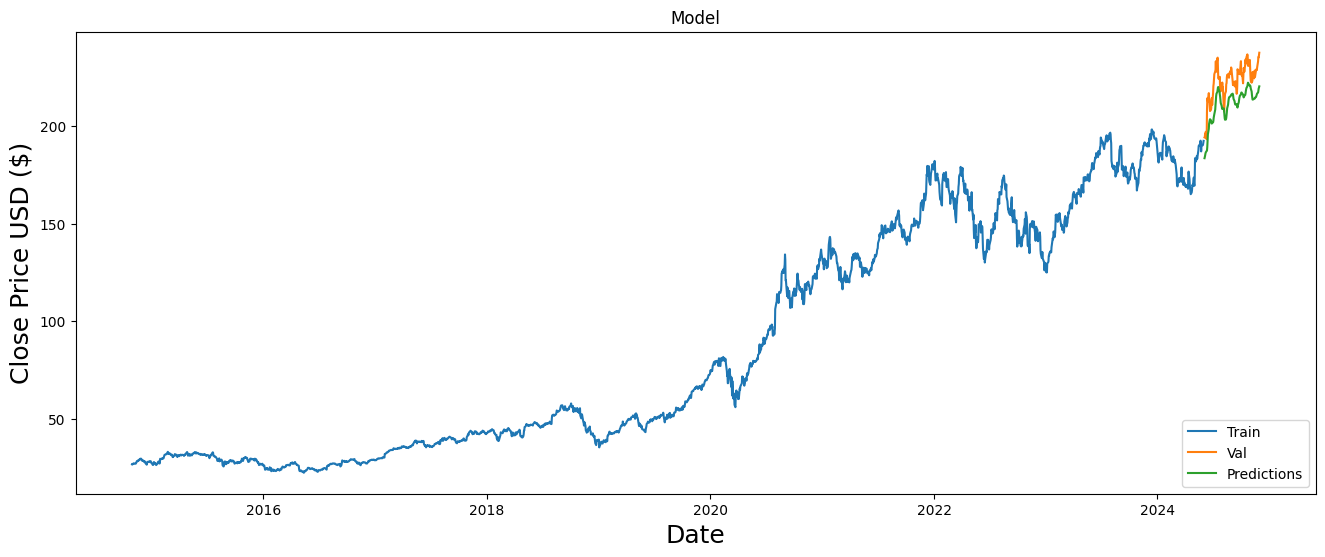

In [ ]:
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [ ]:
# Show the valid and predicted prices
valid

Price,Close,Predictions
Ticker,AAPL,
Date,,
2024-06-03 00:00:00+00:00,194.029999,183.392746
2024-06-04 00:00:00+00:00,194.350006,184.063980
2024-06-05 00:00:00+00:00,195.869995,184.815475
2024-06-06 00:00:00+00:00,194.479996,185.711243
2024-06-07 00:00:00+00:00,196.889999,186.336075
...,...,...
2024-11-22 00:00:00+00:00,229.869995,216.496475
2024-11-25 00:00:00+00:00,232.869995,216.978638


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)  # RMSE is the square root of MSE

# Display the metrics
print("Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")


Evaluation Metrics:
Mean Absolute Error (MAE): 11.83525618295821
Mean Squared Error (MSE): 160.88962111667553
Root Mean Squared Error (RMSE): 12.684227257372658
